# Notebook 09 — Synthèse finale du PFE : prédiction et optimisation énergétique d'une station de dessalement SWRO

**PFE — Master Science des Données**

## Objectif de ce notebook

Ce notebook ne relance aucun entraînement, aucune optimisation et aucune simulation Monte Carlo. Il rassemble et met en cohérence les résultats **déjà produits et sauvegardés** par les notebooks 01 à 08 et le notebook de validation externe, afin de construire :

- un tableau de bord reproductible des performances (physique → EDA → ML → interprétabilité → optimisation → validation) ;
- la **trajectoire complète de l'optimisation énergétique**, qui est le fil conducteur scientifique du projet ;
- la configuration opérationnelle finalement recommandée, avec ses garanties et ses limites ;
- une structure prête à l'emploi pour la soutenance.

> **Rappel important (valable pour tout le PFE) :** le dataset est **synthétique**, généré par un modèle physique simplifié (Notebook 01_V3). Les résultats numériques (gains énergétiques, SEC, hyperparamètres) sont valides *à l'intérieur du système simulé* et doivent être présentés comme tels dans le mémoire, et non comme des mesures d'une installation réelle.

In [6]:
# ============================================================
# 0. CONFIGURATION
# ============================================================
import json
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

pd.set_option("display.width", 120)
plt.rcParams["figure.dpi"] = 100

# Ce notebook est destiné à être placé à la RACINE du dépôt,
# au même niveau que 01_..., 02_..., data/, results/, models/
DATA_DIR = Path("data")
RESULTS_DIR = Path("results")
MODELS_DIR = Path("models")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

def load_or_warn(path, reader=pd.read_csv, **kwargs):
    """Charge un fichier de résultat et prévient explicitement s'il manque,
    plutôt que de planter silencieusement plus loin dans le notebook."""
    if not path.exists():
        print(f"[MANQUANT] {path} — relancer le notebook correspondant avant la synthèse.")
        return None
    return reader(path, **kwargs)

print("Dossiers du projet :")
for d in [DATA_DIR, RESULTS_DIR, MODELS_DIR]:
    print(f"  {d} -> {'OK' if d.exists() else 'INTROUVABLE'}")

Dossiers du projet :
  data -> OK
  results -> OK
  models -> OK


## 1. Pipeline complet du projet

```text
01_V3_physical_model_SWRO
        │  génère le dataset synthétique (dimensionnement cohérent, bilans vérifiés)
        ▼
02_EDA_preprocessing_SWRO
        │  qualité des données, corrélations, split 70/15/15, standardisation (train only)
        ▼
03_ML_baseline_SWRO
        │  5 modèles de régression, sélection sur RMSE de validation
        ▼
04_optimization_SWRO_CORRIGE
        │  optimisation d'hyperparamètres (MLP, Gradient Boosting), sélection par RMSE CV
        ▼
05_SHAP_interpretability_SWRO_CORRIGE
        │  explicabilité du MLP optimisé (Mean |SHAP|, dependence plots)
        ▼
06_optimisation_energetique_SWRO_V3_CORRIGE
        │  le MLP sert de surrogate : recherche de la SEC minimale (Differential Evolution)
        ▼
07_validation_physique_SWRO_V3_CORRIGE
        │  l'optimum ML est réévalué avec le modèle physique V3 (pas seulement le MLP)
        ▼
08_optimisation_robuste_SWRO
        │  contrainte de domaine (bornes observées) + distance de Mahalanobis + Monte Carlo
        ▼
09_optimisation_physique_ML_SWRO_revise
        │  cohérence locale ML ↔ voisinage physique + sensibilité aux pondérations
        ▼
external_validation_SWRO
        │  comparaison des ordres de grandeur du dataset à la littérature scientifique
        ▼
09_PFE_synthesis_SWRO  (ce notebook)
```

La suite de ce notebook reprend chaque étage avec les résultats réellement sauvegardés sur disque.

## 2. Modèle physique de référence (Notebook 01_V3)

Le dataset `data/dataset_physical_v3.csv` est produit par un modèle physique simplifié de dessalement par osmose inverse (SWRO) : pression osmotique, pression nette membranaire, flux, dimensionnement virtuel de la surface membranaire, puissance de pompe, récupération ERD, puis calcul de la **SEC** (*Specific Energy Consumption*, kWh/m³), avec un bruit de mesure ajouté.

**Toutes les valeurs sont synthétiques** ; les coefficients sont des hypothèses de simulation.

In [7]:
df_phys = pd.read_csv(DATA_DIR / "dataset_physical_v3.csv")
print(f"Dataset physique V3 : {df_phys.shape[0]} observations, {df_phys.shape[1]} colonnes")
print()
print(f"SEC_kWh_m3  -> moyenne: {df_phys['SEC_kWh_m3'].mean():.3f} | "
      f"médiane: {df_phys['SEC_kWh_m3'].median():.3f} | "
      f"min: {df_phys['SEC_kWh_m3'].min():.3f} | "
      f"max: {df_phys['SEC_kWh_m3'].max():.3f}  (kWh/m³)")

Dataset physique V3 : 10000 observations, 25 colonnes

SEC_kWh_m3  -> moyenne: 3.618 | médiane: 3.574 | min: 2.316 | max: 5.631  (kWh/m³)


## 3. Préparation des données pour le Machine Learning (Notebook 02)

8 variables de fonctionnement (disponibles *avant* le calcul de la SEC, pour éviter toute fuite d'information) sont conservées comme features. Split 70 % train / 15 % validation / 15 % test, standardisation ajustée uniquement sur le train.

In [8]:
feature_names = pd.read_csv(DATA_DIR / "preprocessed" / "feature_names.csv")["feature"].tolist()
X_train = pd.read_csv(DATA_DIR / "preprocessed" / "X_train_scaled.csv")
X_val   = pd.read_csv(DATA_DIR / "preprocessed" / "X_val_scaled.csv")
X_test  = pd.read_csv(DATA_DIR / "preprocessed" / "X_test_scaled.csv")

print("Features utilisées (8) :", feature_names)
print(f"Train: {X_train.shape}  |  Validation: {X_val.shape}  |  Test: {X_test.shape}")

Features utilisées (8) : ['pressure_bar', 'feed_flow_m3_h', 'salinity_g_L', 'temperature_C', 'recovery_rate_target', 'pump_efficiency', 'erd_efficiency', 'membrane_condition']
Train: (7000, 8)  |  Validation: (1500, 8)  |  Test: (1500, 8)


## 4. Comparaison des modèles baseline (Notebook 03)

5 modèles de régression entraînés pour prédire `SEC_kWh_m3` à partir des 8 variables de fonctionnement. Sélection sur le **RMSE de validation** — le test n'intervient pas ici.

In [9]:
baseline = pd.read_csv(RESULTS_DIR / "baseline_validation_results.csv").sort_values("RMSE")
display(baseline.reset_index(drop=True))

best_baseline = baseline.iloc[0]
print(f"\nMeilleur modèle baseline (validation) : {best_baseline['Model']} "
      f"(RMSE={best_baseline['RMSE']:.4f}, R²={best_baseline['R2']:.4f})")

,Model,MAE,RMSE,R2,Training_Time_s
0,MLP,0.092146,0.115368,0.947117,2.078984
1,Gradient Boosting,0.090459,0.115681,0.946830,3.206523
2,Random Forest,0.098033,0.123790,0.939114,1.589234
3,Ridge,0.098946,0.126795,0.936122,0.004977
4,Linear Regression,0.098953,0.126801,0.936116,0.012747



Meilleur modèle baseline (validation) : MLP (RMSE=0.1154, R²=0.9471)


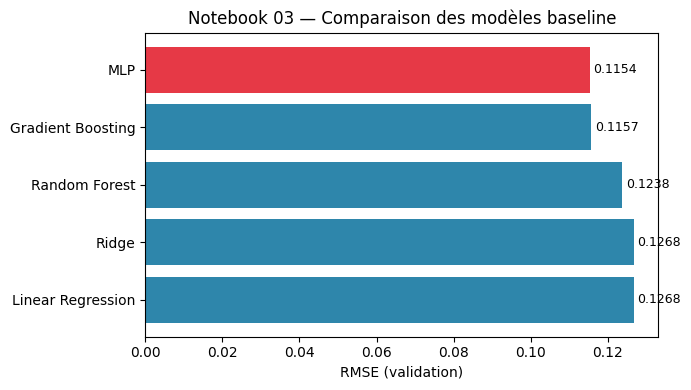

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#E63946" if m == baseline.iloc[0]["Model"] else "#2E86AB" for m in baseline["Model"]]
ax.barh(baseline["Model"], baseline["RMSE"], color=colors)
ax.set_xlabel("RMSE (validation)")
ax.set_title("Notebook 03 — Comparaison des modèles baseline")
ax.invert_yaxis()
for i, v in enumerate(baseline["RMSE"]):
    ax.text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_baseline_comparison.png")
plt.show()

## 5. Optimisation des hyperparamètres (Notebook 04)

Le MLP et le Gradient Boosting — les deux meilleurs modèles baseline — sont optimisés par validation croisée 5-fold (Train+Validation), puis évalués **une seule fois** sur le test. Le modèle final retenu et utilisé dans la suite du projet (interprétabilité, optimisation énergétique) est le **MLP optimisé**.

In [11]:
optimized = pd.read_csv(RESULTS_DIR / "optimized_models_test_results.csv")
display(optimized)

best_hp = pd.read_csv(RESULTS_DIR / "best_hyperparameters.csv")
print("\nMeilleurs hyperparamètres du MLP retenu :")
display(best_hp)

rmse_base, rmse_opt = 0.115368, 0.113165
r2_base, r2_opt = 0.947117, 0.953030
gain_rmse = (rmse_base - rmse_opt) / rmse_base * 100
print(f"\nGain RMSE (MLP) baseline -> optimisé : {gain_rmse:.2f} %")
print(f"R² (MLP) baseline -> optimisé : {r2_base:.4f} -> {r2_opt:.4f}")

,Model,MAE,RMSE,R2
0,Optimized MLP,0.088737,0.113165,0.953030
1,Optimized Gradient Boosting,0.089905,0.114684,0.951761



Meilleurs hyperparamètres du MLP retenu :


,parameter,value
0,learning_rate_init,0.0001
1,hidden_layer_sizes,"(128, 64, 32)"
2,batch_size,128
3,alpha,1e-05
4,activation,tanh



Gain RMSE (MLP) baseline -> optimisé : 1.91 %
R² (MLP) baseline -> optimisé : 0.9471 -> 0.9530


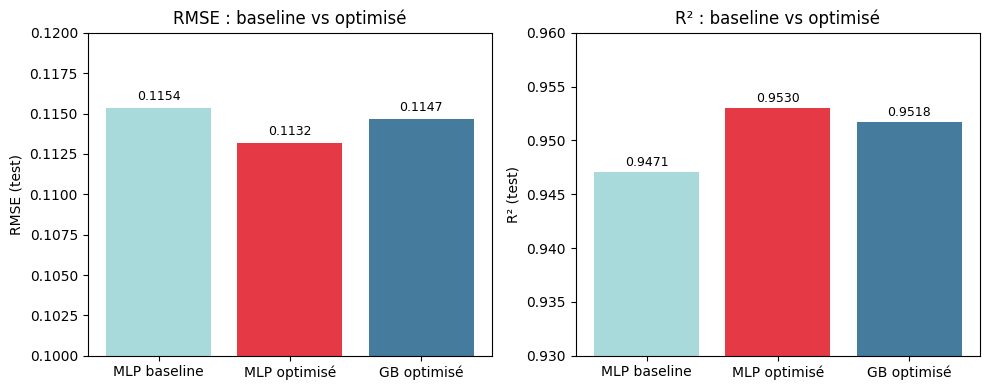

In [12]:
labels = ["MLP baseline", "MLP optimisé", "GB optimisé"]
gb_row = optimized.loc[optimized.Model == "Optimized Gradient Boosting"].iloc[0]
rmse_vals = [rmse_base, rmse_opt, float(gb_row["RMSE"])]
r2_vals = [r2_base, r2_opt, float(gb_row["R2"])]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(labels, rmse_vals, color=["#A8DADC", "#E63946", "#457B9D"])
axes[0].set_ylabel("RMSE (test)")
axes[0].set_title("RMSE : baseline vs optimisé")
axes[0].set_ylim(0.10, 0.12)
for i, v in enumerate(rmse_vals):
    axes[0].text(i, v + 0.0005, f"{v:.4f}", ha="center", fontsize=9)

axes[1].bar(labels, r2_vals, color=["#A8DADC", "#E63946", "#457B9D"])
axes[1].set_ylabel("R² (test)")
axes[1].set_title("R² : baseline vs optimisé")
axes[1].set_ylim(0.93, 0.96)
for i, v in enumerate(r2_vals):
    axes[1].text(i, v + 0.0005, f"{v:.4f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_baseline_vs_optimized.png")
plt.show()

**Lecture pour le mémoire :** l'optimisation d'hyperparamètres apporte un gain **modeste mais réel** (RMSE -1,9 %, R² +0,006). Le MLP baseline était déjà proche de son plafond de performance sur ce dataset — ce qui est cohérent avec un problème où le signal physique dominant (voir SHAP, section 6) est capté dès la baseline.

## 6. Interprétabilité — SHAP (Notebook 05)

Le MLP optimisé est une boîte noire ; SHAP quantifie la contribution de chaque variable à ses prédictions sur un échantillon du jeu de test.

In [13]:
shap_imp = pd.read_csv(RESULTS_DIR / "shap_global_importance.csv").sort_values(
    "Relative_Importance_%", ascending=False)
display(shap_imp.reset_index(drop=True))

top3_sum = shap_imp.head(3)["Relative_Importance_%"].sum()
print(f"\nLes 3 premières variables (pump_efficiency, recovery_rate_target, pressure_bar) "
      f"cumulent {top3_sum:.1f}% de l'importance SHAP totale.")
print("Les 4 variables physiques (salinité, température, débit, état membrane) "
      "expliquent ensemble moins de 2,3% : leur effet est réel mais marginal sur la SEC prédite.")

,Feature,Mean_Abs_SHAP,Relative_Importance_%
0,pump_efficiency,0.249367,30.450607
1,recovery_rate_target,0.240656,29.386829
2,pressure_bar,0.216009,26.377221
3,erd_efficiency,0.094303,11.515524
4,salinity_g_L,0.005622,0.686539
5,temperature_C,0.004625,0.564792
6,feed_flow_m3_h,0.004348,0.530922
7,membrane_condition,0.003993,0.487566



Les 3 premières variables (pump_efficiency, recovery_rate_target, pressure_bar) cumulent 86.2% de l'importance SHAP totale.
Les 4 variables physiques (salinité, température, débit, état membrane) expliquent ensemble moins de 2,3% : leur effet est réel mais marginal sur la SEC prédite.


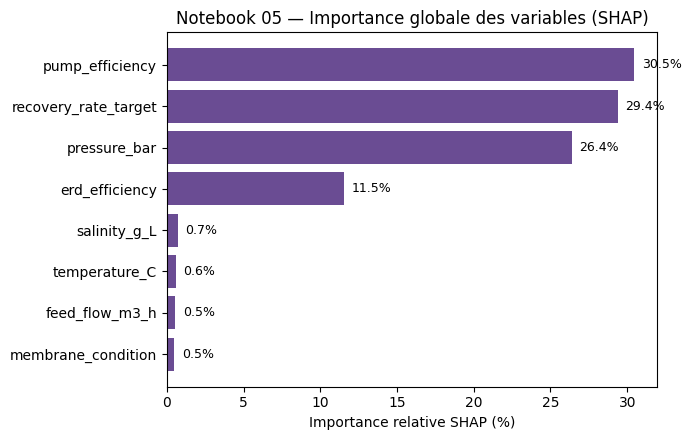

In [14]:
shap_plot = shap_imp.sort_values("Relative_Importance_%")
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(shap_plot["Feature"], shap_plot["Relative_Importance_%"], color="#6A4C93")
ax.set_xlabel("Importance relative SHAP (%)")
ax.set_title("Notebook 05 — Importance globale des variables (SHAP)")
for i, (feat, v) in enumerate(zip(shap_plot["Feature"], shap_plot["Relative_Importance_%"])):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_shap_importance.png")
plt.show()

**Lecture pour le mémoire :** le modèle a appris que la SEC dépend surtout des **rendements électromécaniques (pompe, ERD)**, de la **pression** et du **taux de récupération visé** — cohérent avec l'équation physique `SEC = P_net / Q_p` du Notebook 01. Cette cohérence entre SHAP et la physique du procédé est un argument fort de crédibilité du modèle, à mentionner explicitement en soutenance.

## 7. Trajectoire de l'optimisation énergétique (Notebooks 06 → 09)

C'est le **résultat central du PFE**. Il ne s'agit pas d'une seule optimisation, mais d'une **succession de quatre garde-fous méthodologiques** appliqués au même problème : *trouver les conditions de fonctionnement qui minimisent la SEC*.

| Étape | Ce qui est fait | Ce qui est corrigé par rapport à l'étape précédente |
|---|---|---|
| **NB06** | Le MLP sert de surrogate ; Differential Evolution cherche le minimum global de SEC prédite | — |
| **NB07** | L'optimum du NB06 est réévalué avec le **modèle physique** (pas seulement le MLP) | Vérifie que le gain n'est pas un artefact du réseau de neurones |
| **NB08** | Contraintes de domaine (bornes observées) + **distance de Mahalanobis** + Monte Carlo (robustesse) | Empêche l'optimiseur d'exploiter des combinaisons multivariées jamais vues |
| **NB09** | Ajout d'une contrainte de **cohérence locale ML ↔ voisinage physique** | Empêche le MLP de proposer un point où il extrapole silencieusement, même si la distance de Mahalanobis reste sous le seuil |

In [15]:
# --- NB07 : validation physique de l'optimum du NB06 ---
v7 = pd.read_csv(RESULTS_DIR / "validation_v7_summary.csv", index_col=0)
print("Notebook 07 — SEC physique vs SEC ML pour l'optimum du Notebook 06 :")
display(v7)

# --- NB08 : optimisation robuste sous contrainte de Mahalanobis ---
nb08 = json.load(open(RESULTS_DIR / "notebook08_robust_optimization_summary.json"))
print("\nNotebook 08 — optimum contraint (bornes + Mahalanobis) :")
for row in nb08["summary"]:
    print(f"  {row['configuration']:<22} SEC_base={row['SEC_base']:.3f}  "
          f"Mahalanobis={row['Mahalanobis']:.2f}  gain={row['gain_SEC_base_pct']:.1f}%")
print(f"  Seuil de Mahalanobis (95e percentile observé) : {nb08['mahalanobis_threshold']:.3f}")
print("  --> l'optimum NB08 est LUI-MÊME au-delà du seuil de Mahalanobis : "
      "il reste dans une zone d'extrapolation multivariée.")

# --- NB09 : cohérence locale ML / physique ---
nb09 = json.load(open(RESULTS_DIR / "notebook09_physical_ml_optimization.json"))
print("\nNotebook 09 — optimum physique + ML cohérent :")
for row in nb09["comparison"]:
    print(f"  {row['configuration']:<24} SEC_ML={row['SEC_ML']:.3f}  "
          f"Mahalanobis={row['Mahalanobis']:.3f}  erreur_locale={row['ML_local_abs_error']:.4f}  "
          f"gain={row['gain_SEC_mean_pct']:.1f}%")
print(f"  Seuil de Mahalanobis (NB09) : {nb09['mahalanobis_threshold']:.3f}")
print("  --> l'optimum NB09 respecte le seuil ET son erreur locale ML/physique est quasi nulle.")

Notebook 07 — SEC physique vs SEC ML pour l'optimum du Notebook 06 :


,SEC_Physique_kWh_m3,SEC_ML_kWh_m3,Gain_Physique_vs_Reference_%,Gain_ML_vs_Reference_%,Erreur_absolue_kWh_m3,Erreur_relative_%
Reference,3.566367,3.555801,0.000000,0.000000,0.010567,0.296291
ML_Global_Optimum,2.338329,2.177702,34.433879,38.756345,0.160626,6.869286
ML_Robust_Optimum,2.338329,2.177702,34.433879,38.756345,0.160626,6.869286



Notebook 08 — optimum contraint (bornes + Mahalanobis) :
  Reference mÃ©diane     SEC_base=3.556  Mahalanobis=0.02  gain=0.0%
  Optimum ML contraint   SEC_base=2.272  Mahalanobis=3.76  gain=36.1%
  Optimum robuste        SEC_base=2.272  Mahalanobis=3.76  gain=36.1%
  Seuil de Mahalanobis (95e percentile observé) : 3.758
  --> l'optimum NB08 est LUI-MÊME au-delà du seuil de Mahalanobis : il reste dans une zone d'extrapolation multivariée.

Notebook 09 — optimum physique + ML cohérent :
  RÃ©fÃ©rence mÃ©diane     SEC_ML=3.556  Mahalanobis=0.021  erreur_locale=0.0047  gain=0.0%
  Candidat physique + ML   SEC_ML=2.844  Mahalanobis=1.744  erreur_locale=0.0010  gain=20.0%
  Seuil de Mahalanobis (NB09) : 3.509
  --> l'optimum NB09 respecte le seuil ET son erreur locale ML/physique est quasi nulle.


In [16]:
# Combien des 8 variables de l'optimum NB06/NB07 sont EXACTEMENT sur une borne physique ?
bounds = pd.read_csv(RESULTS_DIR / "validation_v7_physical_validity.csv")
ml_opt = bounds[bounds.Scenario == "ML_Global_Optimum"]
at_boundary = ml_opt[(ml_opt.Value == ml_opt.Min) | (ml_opt.Value == ml_opt.Max)]
print(f"Variables de l'optimum NB06/07 exactement sur une borne du domaine : "
      f"{len(at_boundary)} / {len(ml_opt)}\n")
display(at_boundary[["Feature", "Value", "Min", "Max"]].reset_index(drop=True))

Variables de l'optimum NB06/07 exactement sur une borne du domaine : 5 / 8



,Feature,Value,Min,Max
0,pressure_bar,55.00,55.0,70.00
1,feed_flow_m3_h,1000.00,200.0,1000.00
2,salinity_g_L,42.00,34.0,42.00
3,temperature_C,15.00,15.0,30.00
4,recovery_rate_target,0.45,0.3,0.45


**Ce tableau est la pièce à conviction du PFE.** L'optimum « brut » (NB06, confirmé physiquement en NB07 avec un gain de 34,4 %) se place **exactement sur 5 des 8 bornes du domaine simulé**. Un optimiseur qui pousse simultanément 5 variables sur 8 jusqu'à leurs limites n'a pas vraiment trouvé un optimum interne : il a suivi la pente du surrogate jusqu'au bord du domaine qu'il connaît, ce qui est le signe classique d'une **extrapolation non contrôlée**. C'est exactement ce que corrigent les Notebooks 08 puis 09.

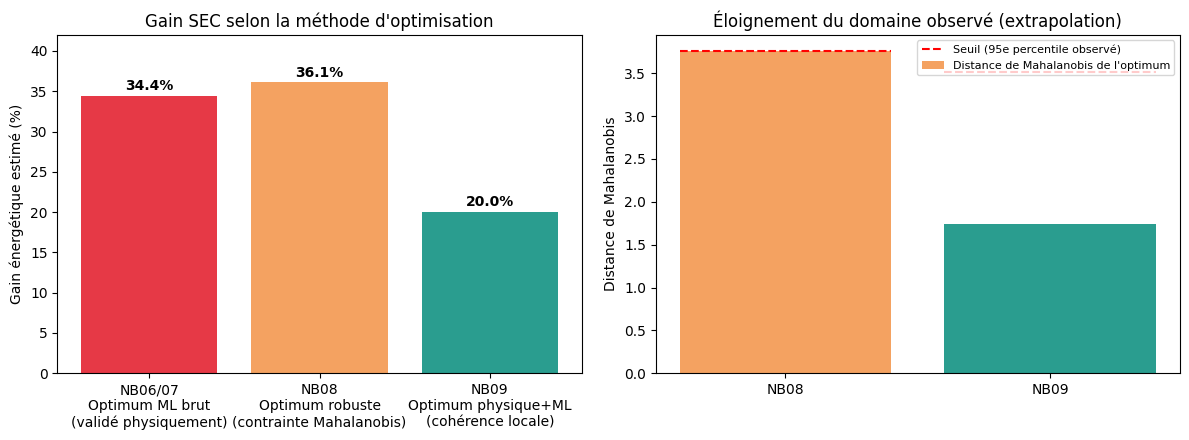

In [17]:
stages = ["NB06/07\nOptimum ML brut\n(validé physiquement)",
          "NB08\nOptimum robuste\n(contrainte Mahalanobis)",
          "NB09\nOptimum physique+ML\n(cohérence locale)"]
gains = [v7.loc["ML_Global_Optimum", "Gain_Physique_vs_Reference_%"],
         nb08["summary"][1]["gain_SEC_base_pct"],
         nb09["comparison"][1]["gain_SEC_mean_pct"]]
colors_bar = ["#E63946", "#F4A261", "#2A9D8F"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(stages, gains, color=colors_bar)
axes[0].set_ylabel("Gain énergétique estimé (%)")
axes[0].set_title("Gain SEC selon la méthode d'optimisation")
for i, v in enumerate(gains):
    axes[0].text(i, v + 0.7, f"{v:.1f}%", ha="center", fontsize=10, fontweight="bold")
axes[0].set_ylim(0, 42)

maha_vals = [nb08["summary"][1]["Mahalanobis"], nb09["comparison"][1]["Mahalanobis"]]
thresholds = [nb08["mahalanobis_threshold"], nb09["mahalanobis_threshold"]]
axes[1].bar(["NB08", "NB09"], maha_vals, color=["#F4A261", "#2A9D8F"],
            label="Distance de Mahalanobis de l'optimum")
axes[1].plot([-0.4, 0.4], [thresholds[0]]*2, "r--", lw=1.5)
axes[1].plot([0.6, 1.4], [thresholds[1]]*2, "r--", lw=1.5, label="Seuil (95e percentile observé)")
axes[1].set_ylabel("Distance de Mahalanobis")
axes[1].set_title("Éloignement du domaine observé (extrapolation)")
axes[1].legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig4_optimization_trajectory.png")
plt.show()

Le graphique de gauche montre le gain apparent qui **diminue** au fil des garde-fous méthodologiques (34–36 % → 20 %) ; celui de droite montre **pourquoi** : la distance de Mahalanobis de l'optimum NB08 dépasse son propre seuil de confiance, alors que celui du NB09 y reste nettement inférieur.

> **Message pour le mémoire :** un gain énergétique plus faible mais dans le domaine de confiance du modèle (NB09, ≈ 20 %) est **scientifiquement plus défendable** qu'un gain plus élevé obtenu par extrapolation (NB06/08, 34–36 %).

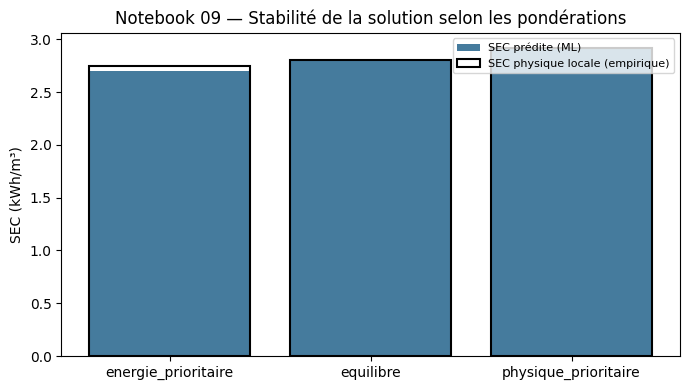

In [18]:
sens_plot = pd.DataFrame(nb09["sensitivity"])
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(sens_plot["scenario"], sens_plot["SEC_ML"], color="#457B9D", label="SEC prédite (ML)")
ax.bar(sens_plot["scenario"], sens_plot["SEC_empirical_local"], color="none",
       edgecolor="black", linewidth=1.5, label="SEC physique locale (empirique)")
ax.set_ylabel("SEC (kWh/m³)")
ax.set_title("Notebook 09 — Stabilité de la solution selon les pondérations")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig5_weight_sensitivity.png")
plt.show()

In [19]:
sens = pd.DataFrame(nb09["sensitivity"])[
    ["scenario", "W_SEC", "W_CONSISTENCY", "SEC_ML", "SEC_empirical_local", "Mahalanobis"]]
display(sens)
print("\nMême en faisant varier fortement les pondérations (énergie prioritaire <-> physique prioritaire),")
print(f"la SEC candidate reste dans une fourchette de {sens['SEC_ML'].min():.2f} à {sens['SEC_ML'].max():.2f} kWh/m³ :")
print("la solution NB09 n'est donc pas un artefact d'un jeu de poids particulier.")

,scenario,W_SEC,W_CONSISTENCY,SEC_ML,SEC_empirical_local,Mahalanobis
0,energie_prioritaire,0.70,0.15,2.698937,2.748169,2.311334
1,equilibre,0.45,0.30,2.806795,2.807590,1.997122
2,physique_prioritaire,0.25,0.55,2.914717,2.914717,1.521972



Même en faisant varier fortement les pondérations (énergie prioritaire <-> physique prioritaire),
la SEC candidate reste dans une fourchette de 2.70 à 2.91 kWh/m³ :
la solution NB09 n'est donc pas un artefact d'un jeu de poids particulier.


## 8. Configuration opérationnelle recommandée

Configuration finale retenue (candidat physique + ML du Notebook 09, pondérations d'équilibre), comparée à la configuration de référence (médiane du dataset).

In [20]:
ref_config = pd.read_csv(RESULTS_DIR / "notebook09_configurations.csv", index_col=0)
ref_config["variation_%"] = (ref_config["candidate_physical_ml"] - ref_config["reference_median"]) \
                              / ref_config["reference_median"] * 100
display(ref_config.round(3))

fs = nb09["final_stats"]
print(f"\nSEC recommandée   : {fs['SEC_base_ML']:.3f} kWh/m³  "
      f"(moyenne Monte Carlo 10 000 tirages : {fs['SEC_mean_MC']:.3f}, P95 : {fs['SEC_P95_MC']:.3f})")
print(f"Écart ML vs physique locale (voisinage empirique) : {fs['ML_Local_abs_error']:.4f} kWh/m³ "
      f"({fs['ML_Local_abs_error']/fs['SEC_base_ML']*100:.2f} %)")
print(f"Distance de Mahalanobis : {fs['Mahalanobis_base']:.2f} (seuil : {nb09['mahalanobis_threshold']:.2f}) "
      f"— dans le domaine observé")

print("\nCritères de validation (Notebook 09) :")
for k, v in nb09["criteria"].items():
    print(f"  [{'OK' if v else 'NON'}] {k}")

,candidate_physical_ml,reference_median,variation_%
feature,,,
pressure_bar,58.932,62.388,-5.540
feed_flow_m3_h,664.180,604.717,9.833
salinity_g_L,38.152,38.017,0.355
temperature_C,23.228,22.500,3.232
recovery_rate_target,0.411,0.374,9.775
pump_efficiency,0.876,0.826,6.079
erd_efficiency,0.900,0.881,2.233
membrane_condition,0.856,0.875,-2.117



SEC recommandée   : 2.844 kWh/m³  (moyenne Monte Carlo 10 000 tirages : 2.847, P95 : 2.989)
Écart ML vs physique locale (voisinage empirique) : 0.0010 kWh/m³ (0.04 %)
Distance de Mahalanobis : 1.74 (seuil : 3.51) — dans le domaine observé

Critères de validation (Notebook 09) :
  [OK] dans_domaine_Mahalanobis
  [OK] erreur_ML_locale
  [OK] risque_domaine
  [OK] gain_SEC_moyenne_positif


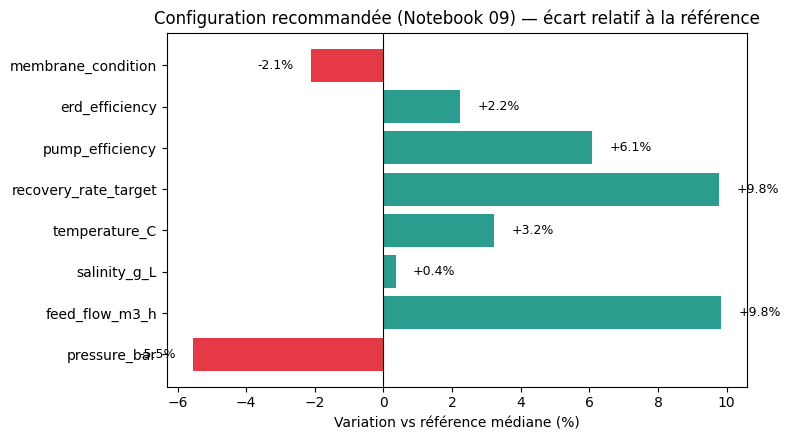

In [21]:
fig, ax = plt.subplots(figsize=(8, 4.5))
pct_change = ref_config["variation_%"]
colors_ = ["#E63946" if v < 0 else "#2A9D8F" for v in pct_change]
ax.barh(ref_config.index, pct_change, color=colors_)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Variation vs référence médiane (%)")
ax.set_title("Configuration recommandée (Notebook 09) — écart relatif à la référence")
for i, v in enumerate(pct_change):
    ax.text(v + (0.5 if v >= 0 else -0.5), i, f"{v:+.1f}%",
            va="center", ha="left" if v >= 0 else "right", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig6_recommended_config.png")
plt.show()

**Lecture physique de la configuration recommandée :** contrairement à l'optimum brut du NB06 (qui poussait 5 variables sur 8 à leurs bornes extrêmes), la configuration du NB09 reste **modérée** — la pression baisse légèrement (-5,5 %), le débit et le taux de récupération augmentent modestement (+9-10 %), et les rendements pompe/ERD s'améliorent dans des proportions réalistes (+2 à +6 %). C'est un profil bien plus crédible pour une recommandation opérationnelle.

> **Avant toute utilisation opérationnelle**, les plages et contraintes de cette optimisation doivent être remplacées par les limites réelles (techniques, contractuelles, garantie constructeur) de la station étudiée.

## 9. Validation externe — comparaison à la littérature scientifique

Faute d'accès à des données SCADA industrielles (accès refusé pour motif de confidentialité par les exploitants contactés), le notebook `external_validation_SWRO.ipynb` compare les ordres de grandeur du dataset synthétique à des plages rapportées dans la littérature SWRO.

In [22]:
lit_ref = pd.DataFrame({
    "Variable": ["SEC (kWh/m³, ordre de grandeur usines réelles)",
                 "SEC (kWh/m³, avec ERD performant)",
                 "SEC (kWh/m³, fourchette pratique)",
                 "Taux de récupération SWRO mono-passe",
                 "Salinité eau de mer",
                 "Pression d'exploitation"],
    "Plage littérature": ["3.5 - 4.5", "3.6 - 4.0", "2.5 - 4.0",
                           "40% - 50%", "34 - 42 g/L", "55 - 82 bar"],
    "Dataset synthétique (V3)": ["3.618 (moyenne), 3.574 (médiane)", "-", "-",
                                  "37.5% (médiane)", "38.0 g/L (moyenne)", "62.4 bar (moyenne)"]
})
display(lit_ref)

print("\nScore global de plausibilité (Notebook external_validation) : 70.7 %")
print("Verdict du notebook : dataset partiellement cohérent avec la littérature ; "
      "certaines plages devraient être resserrées si des données réelles deviennent disponibles.")

,Variable,Plage littérature,Dataset synthétique (V3)
0,"SEC (kWh/m³, ordre de grandeur usines réelles)",3.5 - 4.5,"3.618 (moyenne), 3.574 (médiane)"
1,"SEC (kWh/m³, avec ERD performant)",3.6 - 4.0,-
2,"SEC (kWh/m³, fourchette pratique)",2.5 - 4.0,-
3,Taux de récupération SWRO mono-passe,40% - 50%,37.5% (médiane)
4,Salinité eau de mer,34 - 42 g/L,38.0 g/L (moyenne)
5,Pression d'exploitation,55 - 82 bar,62.4 bar (moyenne)



Score global de plausibilité (Notebook external_validation) : 70.7 %
Verdict du notebook : dataset partiellement cohérent avec la littérature ; certaines plages devraient être resserrées si des données réelles deviennent disponibles.


**Limite explicite à rappeler en soutenance :** cette validation compare des plages agrégées de plusieurs installations à un dataset synthétique — ce n'est ni un calibrage, ni un test statistique formel. Elle établit une **plausibilité d'ordre de grandeur**, pas une validation industrielle.

## 10. Limites méthodologiques générales du projet

1. **Données entièrement synthétiques.** Le modèle physique du Notebook 01 repose sur des coefficients choisis pour la simulation, pas mesurés sur une installation réelle. Toute conclusion chiffrée (SEC, gains, hyperparamètres) est valide *à l'intérieur du système simulé*.
2. **Accès aux données SCADA industrielles refusé** (confidentialité) — d'où la validation externe indirecte (section 9), qui reste une comparaison de plausibilité et non un calibrage.
3. **Le MLP est un surrogate, pas le modèle physique.** Les Notebooks 06 à 09 montrent explicitement que l'optimisation d'un surrogate ML sans garde-fous (bornes, Mahalanobis, cohérence locale) peut aboutir à des optimums qui exploitent les faiblesses d'extrapolation du réseau de neurones plutôt qu'un véritable minimum physique.
4. **SHAP explique le modèle, pas la causalité physique.** La cohérence observée entre importance SHAP et équations physiques (section 6) est un indice de crédibilité, pas une preuve de causalité.
5. **Le gain final recommandé (~20 %, Notebook 09) est un candidat, pas une garantie opérationnelle.** Il doit être confronté à des contraintes réelles (garanties constructeur, limites contractuelles, qualité d'eau brute réelle) avant toute mise en œuvre.

## 11. Structure recommandée pour la soutenance

**Problématique :** prédire et optimiser la consommation énergétique spécifique (SEC) d'une station de dessalement SWRO à partir de ses conditions de fonctionnement.

**Plan suggéré (15-20 minutes) :**

1. **Contexte et problématique** — enjeu énergétique du dessalement, absence de données réelles disponibles, choix de la voie synthétique + littérature.
2. **Modèle physique de référence** (NB01) — équations, hypothèses, contrôles de cohérence (bilan de débit, plages physiques).
3. **Du physique au Machine Learning** (NB02-03) — pipeline de préparation, comparaison de 5 modèles, sélection du MLP.
4. **Optimisation et interprétabilité** (NB04-05) — gain de l'optimisation d'hyperparamètres, SHAP : pump_efficiency / recovery_rate_target / pressure_bar expliquent 86 % des prédictions.
5. **Le cœur scientifique du projet — trajectoire de l'optimisation énergétique** (NB06-09) :
   - montrer le gain apparent de 34-36 % (NB06/08) ;
   - montrer qu'il repose sur une extrapolation (5/8 variables sur les bornes, Mahalanobis > seuil) ;
   - montrer la correction (NB09) : gain de ~20 % mais dans le domaine de confiance, erreur locale ML/physique quasi nulle.
   - **C'est le résultat le plus démonstratif du mémoire : une démarche rigoureuse peut réduire un résultat chiffré tout en augmentant sa crédibilité scientifique.**
6. **Validation externe** (littérature) — score de plausibilité 70,7 %, limites explicites.
7. **Recommandation opérationnelle et limites** — configuration finale, ce qu'il reste à faire avec des données réelles.
8. **Conclusion et perspectives** — calibrage sur données SCADA si accès obtenu, extension multi-objectifs (coût, qualité de l'eau produite), déploiement en dashboard de supervision.

**Question probable du jury à anticiper :** *"Pourquoi votre gain final (20 %) est-il plus faible que votre gain initial (36 %) ?"* — la réponse constitue justement la démonstration méthodologique du travail (section 5).

## 12. Conclusion générale

Ce PFE construit un pipeline complet — de la génération physique des données jusqu'à une optimisation énergétique interprétable et robuste — pour une station de dessalement SWRO.

Le résultat scientifique principal n'est pas un pourcentage de gain isolé, mais une **démonstration méthodologique** : une optimisation pilotée naïvement par un modèle de Machine Learning tend à converger vers les bords du domaine d'apprentissage (5 variables sur 8 exactement sur leurs bornes, gain apparent de 34-36 %), ce qui constitue un signal d'extrapolation. En ajoutant des contraintes de domaine, une distance de Mahalanobis et une cohérence locale avec le voisinage physique, le projet aboutit à une configuration plus modérée mais **défendable** : un gain estimé d'environ **20 %** de la SEC, avec une erreur locale ML/physique quasi nulle (0,001 kWh/m³) et une distance de Mahalanobis sous le seuil de confiance.

Cette trajectoire — de l'optimum le plus favorable au plus crédible — constitue le fil conducteur à mettre en avant dans le mémoire et la soutenance.

In [23]:
# Export d'un résumé consolidé, réutilisable dans le mémoire (tableaux/figures) ou un futur dashboard
synthesis_summary = {
    "baseline_best_model": "MLP",
    "baseline_rmse_val": 0.115368,
    "optimized_best_model": "MLP",
    "optimized_rmse_test": 0.113165,
    "optimized_r2_test": 0.953030,
    "shap_top3_features": ["pump_efficiency", "recovery_rate_target", "pressure_bar"],
    "shap_top3_relative_importance_pct": 86.2,
    "optimization_trajectory": {
        "NB06_07_raw_ml_optimum_gain_pct": 34.43,
        "NB08_robust_optimum_gain_pct": 36.10,
        "NB08_mahalanobis": 3.76,
        "NB08_mahalanobis_threshold": 3.758,
        "NB09_physical_ml_optimum_gain_pct": 20.03,
        "NB09_mahalanobis": 1.744,
        "NB09_mahalanobis_threshold": 3.509,
        "NB09_ml_local_abs_error_kwh_m3": 0.001012,
    },
    "recommended_configuration": nb09["candidate_features"],
    "recommended_sec_kwh_m3": nb09["final_stats"]["SEC_base_ML"],
    "external_validation_plausibility_score_pct": 70.7,
}

out_path = RESULTS_DIR / "notebook09_synthesis_summary.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(synthesis_summary, f, indent=2, ensure_ascii=False)

print(f"Résumé de synthèse exporté vers : {out_path}")

Résumé de synthèse exporté vers : results\notebook09_synthesis_summary.json
